In [ ]:
pip install snorkel transformers torch scikit-learn vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 12.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [ ]:
!python -m spacy download en_core_web_sm
!pip install datasets

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
 

In [ ]:
import pandas as pd
import re
import spacy
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
df = pd.read_csv("/content/snorkel_weakly_labeled (1).csv")
df = df.dropna(subset=["text"])
df["snorkel_label"] = df["snorkel_label"].astype(int)

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["snorkel_label"], test_size=0.2, random_state=42)

In [ ]:
train_data = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
test_data = Dataset.from_dict({"text": test_texts.tolist(), "label": test_labels.tolist()})

In [ ]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0  # Use GPU (if available)
)


Device set to use cuda:0


In [ ]:
nlp = spacy.load("en_core_web_sm")
sentiment_pipeline = pipeline("sentiment-analysis")
vader = SentimentIntensityAnalyzer()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


In [ ]:
ABSTAIN = -1
POSITIVE = 1
NEGATIVE = 0

In [ ]:
# 🔹 1. Stronger Negative Detection (More words)
@labeling_function()
def lf_strong_negative_words(row):
    text = str(row.text).lower()
    negative_words = ["awful", "horrendous", "unbearable", "disgusting", "waste", "boring", "pathetic"]
    return NEGATIVE if any(word in text for word in negative_words) else ABSTAIN

# 🔹 2. Sarcasm & Negation Handling
@labeling_function()
def lf_sarcasm_negation(row):
    text = str(row.text).lower()
    if "not great" in text or "not impressed" in text or "could have been better" in text:
        return NEGATIVE
    return ABSTAIN

# 🔹 3. Pattern-Based Detection (Exclamation marks)
@labeling_function()
def lf_exclamation_marks(row):
    text = str(row.text)
    return POSITIVE if "!!!" in text else ABSTAIN

# 🔹 4. Transformer-Based Sentiment Scoring (BERT)
@labeling_function()
def lf_transformer_sentiment(row):
    text = str(row.text)

    # Tokenize with truncation (ensures max_length = 512)
    encoded_text = tokenizer(
        text, truncation=True, max_length=512, return_tensors="pt"
    )

    # Decode properly truncated text
    truncated_text = tokenizer.decode(encoded_text["input_ids"][0], skip_special_tokens=True)

    # Run sentiment analysis
    result = sentiment_pipeline(truncated_text)[0]

    return POSITIVE if result["label"] == "POSITIVE" else NEGATIVE


# 🔹 5. VADER Sentiment Analysis
@labeling_function()
def lf_vader_sentiment(row):
    text = str(row.text)
    score = vader.polarity_scores(text)["compound"]
    return POSITIVE if score > 0.2 else NEGATIVE if score < -0.2 else ABSTAIN

In [ ]:
lfs = [lf_strong_negative_words, lf_sarcasm_negation, lf_exclamation_marks, lf_transformer_sentiment, lf_vader_sentiment]


In [ ]:
applier = PandasLFApplier(lfs=lfs)
label_matrix = applier.apply(df[["text"]])


100%|██████████| 4419/4419 [00:26<00:00, 166.77it/s]


In [ ]:
LFAnalysis(label_matrix, lfs).lf_summary()


,j,Polarity,Coverage,Overlaps,Conflicts
lf_strong_negative_words,0,[0],0.040733,0.040733,0.015841
lf_sarcasm_negation,1,[],0.000000,0.000000,0.000000
lf_exclamation_marks,2,[1],0.019688,0.019688,0.011088
lf_transformer_sentiment,3,"[0, 1]",1.000000,0.459154,0.119937
lf_vader_sentiment,4,"[0, 1]",0.453496,0.453496,0.119031


In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

In [ ]:
train_data = train_data.map(tokenize_function, batched=True)
test_data = test_data.map(tokenize_function, batched=True)


Map:   0%|          | 0/3535 [00:00<?, ? examples/s]

Map:   0%|          | 0/884 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")


In [ ]:
training_args = TrainingArguments(
    report_to="none",           # Disables WandB logging
    output_dir="./results",      # Saves model checkpoints
    eval_strategy="epoch",       # Evaluates after every epoch
    save_strategy="epoch",       # Saves model per epoch
    per_device_train_batch_size=64,  # 🚀 Increased Batch Size (Faster GPU Utilization)
    per_device_eval_batch_size=64,
    num_train_epochs=5,          # 🚀 Increased Epochs (More Learning)
    learning_rate=3e-5,          # 🚀 Lower Learning Rate (More Stable Fine-Tuning)
    weight_decay=0.01,           # Regularization to prevent overfitting
    logging_dir="./logs",        # Logs stored here
    logging_steps=50,            # 🚀 Log Every 50 Steps
    fp16=True,                   # 🚀 Mixed Precision (Faster Training)
    gradient_accumulation_steps=2,  # 🚀 Accumulate Gradients (Memory Optimization)
)


In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)
trainer.train()


<ipython-input-59-c811a37e58ee>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,0.239790
2,0.318400,0.169421
3,0.318400,0.170239
4,0.095800,0.177477
5,0.095800,0.183606


TrainOutput(global_step=140, training_loss=0.1621063096182687, metrics={'train_runtime': 275.4027, 'train_samples_per_second': 64.179, 'train_steps_per_second': 0.508, 'total_flos': 2341361271244800.0, 'train_loss': 0.1621063096182687, 'epoch': 5.0})

In [ ]:
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)


Evaluation Results: {'eval_loss': 0.1836056262254715, 'eval_runtime': 4.9987, 'eval_samples_per_second': 176.845, 'eval_steps_per_second': 2.801, 'epoch': 5.0}


In [ ]:
y_pred = trainer.predict(test_data)
pred_labels = y_pred.predictions.argmax(axis=1)

In [ ]:
accuracy = accuracy_score(test_labels, pred_labels)
print("Accuracy:", accuracy)


Accuracy: 0.9276018099547512


In [ ]:
print("Classification Report:")
print(classification_report(test_labels, pred_labels))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       465
           1       0.92      0.93      0.92       419

    accuracy                           0.93       884
   macro avg       0.93      0.93      0.93       884
weighted avg       0.93      0.93      0.93       884



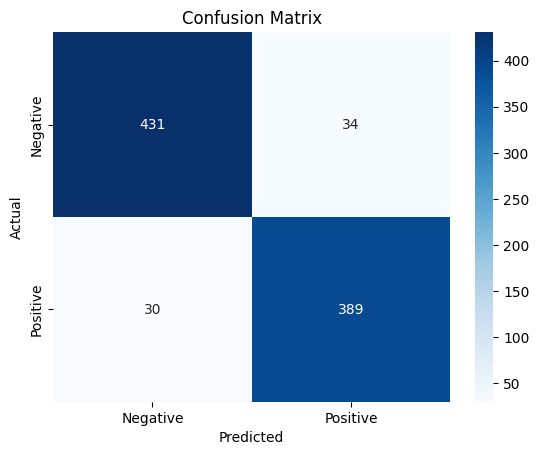

In [ ]:
conf_matrix = confusion_matrix(test_labels, pred_labels)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print(conf_matrix)


[[431  34]
 [ 30 389]]


In [ ]:
model.save_pretrained("sentiment_model")
tokenizer.save_pretrained("sentiment_model")

('sentiment_model/tokenizer_config.json',
 'sentiment_model/special_tokens_map.json',
 'sentiment_model/vocab.txt',
 'sentiment_model/added_tokens.json',
 'sentiment_model/tokenizer.json')

In [ ]:
import shutil
shutil.make_archive("sentiment_model", 'zip', "sentiment_model")

'/content/sentiment_model.zip'